# Spotify Recommender System – Part 1: Exploratory Data Analysis
**Author:** Miguel Vásquez  
**Date:** 19 September 2025  
**Updated:** 2 October 2025  

---

## 1. Introduction  

Music recommendation is one of the most popular and challenging applications of recommender systems. With millions of playlists created daily, streaming platforms such as **Spotify** must provide accurate and personalized suggestions that enhance user experience and engagement.

In this project, we focus on building a **Recommender System** using data derived from the **Spotify Million Playlist Dataset (MPD)**, originally released for the **RecSys Challenge 2018**. The MPD contains **1 million playlists** created between January 2010 and October 2017, including track metadata, playlist titles, and editing information.

To balance **scalability** and **practicality** for research and reproducibility, we construct a **subset of 500,000 playlists** from the original MPD. This subset is large enough to capture the diversity of user behavior while remaining feasible to train models on available hardware.

The main objectives of this project are:
1. Perform exploratory data analysis (EDA) on the Spotify playlists subset.
2. Implement recommendation models, ranging from **baseline heuristics** to **collaborative filtering** and **deep learning-based approaches**.
3. Evaluate models using ranking-aware metrics such as **Precision@K, Recall@K**, and **NDCG@K**.
4. Discuss practical considerations like scalability, diversity, and novelty in music recommendations.

---

## 2. Dataset  
### 2.1 Source

The dataset originates from the **Spotify Million Playlist Dataset (RecSys Challenge 2018)**:
- **Reference**:
    Ching-Wei Chen, Paul Lamere, Markus Schedl, and Hamed Zamani. _RecSys Challenge 2018: Automatic Music Playlist Continuation_. Proceedings of the 12th ACM Conference on Recommender Systems (RecSys ’18), 2018.

### 2.2 Subset Construction

- From the original **1 million playlists**, we selected a subset of **500,000 playlists** for all experiments.
- Original dataset size: ~6 GB compressed, ~90 GB uncompressed.
- Subset size: ~4 GB compressed, ~65 GB uncompressed (Parquet format for efficiency).
- Format: JSON → Parquet for efficient processing.

> **Note**: LightFM with item features and WARP loss was originally planned, but training on even 50k playlists caused the kernel to crash due to memory constraints (32 GB RAM). Reducing to 10k playlists would have compromised dataset realism. Consequently, **ALS (Alternating Least Squares)** is used as the primary model.

---

## 3. Objectives of this notebook

In this first notebook, we will:
- Load and preprocess the subset of 500,000 playlists.
- Explore basic statistics including number of playlists, tracks, and artists.
- Visualize data distributions such as playlist length, track frequency, and artist popularity.
- Examine sparsity and long-tail patterns in playlist–track interactions.
- Provide the foundation for building baseline and advanced recommendation models.
- Document practical constraints and discuss potential scaling and future improvements.

---

## 4. Exploratory Data Analysis (EDA)
The EDA will cover:
1. **Data Overview**: Number of playlists, total tracks, unique artists.
2. **Distributions**: Playlist lengths, track frequency, artist popularity.
3. **Sparsity Analysis**: Fraction of interactions vs. possible interactions, long-tail patterns.
4. **Insights for Modeling**: Identify patterns relevant for collaborative filtering and other recommendation strategies.

> All analyses are conducted on the **500,000 playlist subset**, ensuring results are representative of a realistic scenario for music recommendation.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set seaborn style
sns.set_palette("Set3")

### 4.1 Load Subset
We load the **150k subset** created from the Spotify Million Playlist Dataset (MPD). This subse

In [2]:
import sys
from pathlib import Path

# Add the parent directory to sys.path so 'src' can be imported
sys.path.append(str(Path.cwd().parent))

from src.data_pipeline import load_subset
from IPython.display import Markdown, display
import os
# Change working directory to the project root
os.chdir("..")

df = load_subset(force_extract=False, reduced=False)
display(Markdown(f"Total playlists: {df.shape[0]}"))
df.head()

Loading subset from data\subset\spotify_million_playlist_dataset.parquet...


Total playlists: 500000

,name,collaborative,pid,modified_at,num_tracks,num_albums,num_followers,tracks,num_edits,duration_ms,num_artists,description
0,Throwbacks,false,0,1493424000,52,47,1,"[{'album_name': 'The Cookbook', 'album_uri': '...",6,11532414,37,None
1,Awesome Playlist,false,1,1506556800,39,23,1,"[{'album_name': 'Eye Of The Tiger', 'album_uri...",5,11656470,21,None
2,korean,false,2,1505692800,64,51,1,"[{'album_name': 'On And On', 'album_uri': 'spo...",18,14039958,31,None
3,mat,false,3,1501027200,126,107,1,"[{'album_name': 'French Festival', 'album_uri'...",4,28926058,86,None
4,90s,false,4,1401667200,17,16,2,[{'album_name': 'Mellon Collie and the Infinit...,7,4335282,16,None


### 4.2 Flatten Tracks for Analysis
Each playlist contains a list of tracks with metadata nested inside the `tracks` column.  
To facilitate analysis of track and artist popularity, we need to **flatten this column** so that each track occupies a single row in a new DataFrame.

The resulting `tracks_df` will have one row per track, with the following fields:
- `playlist_id`: ID of the playlist the track belongs to
- `track_name`: Name of the track
- `artist_name`: Name of the primary artist

In [13]:
tracks_expanded = []
for _, row in df.iterrows():
    for t in row["tracks"]:
        tracks_expanded.append({
            "playlist_id": row["pid"],
            "track_uri": t["track_uri"].replace("spotify:track:", ""),
            "track_name": t["track_name"],
            "artist_name": t["artist_name"]
        })

tracks_df = pd.DataFrame(tracks_expanded)

# Save flattened tracks
os.makedirs("data/subset", exist_ok=True)
tracks_df.to_parquet("data/subset/tracks_subset.parquet", index=False)

print(tracks_df.head())
display(Markdown("tracks_subset.parquet saved successfully!"))

   playlist_id               track_uri  \
0            0  0UaMYEvWZi0ZqiDOoHU3YI   
1            0  6I9VzXrHxO9rA9A5euc8Ak   
2            0  0WqIKmW4BTrj3eJFmnCKMv   
3            0  1AWQoqb9bSvzTjaLralEkT   
4            0  1lzr43nnXAijIGYnCT8M8H   

                                   track_name        artist_name  
0  Lose Control (feat. Ciara & Fat Man Scoop)      Missy Elliott  
1                                       Toxic     Britney Spears  
2                               Crazy In Love            Beyoncé  
3                              Rock Your Body  Justin Timberlake  
4                                It Wasn't Me             Shaggy  


tracks_subset.parquet saved successfully!

### 4.3 Basic Statistics
We begin by exploring the **numeric features** of playlists.

In [4]:
df.describe()

,pid,modified_at,num_tracks,num_albums,num_followers,num_edits,duration_ms,num_artists
count,500000.00000,5.000000e+05,500000.000000,500000.000000,500000.000000,500000.000000,5.000000e+05,500000.000000
mean,294361.50000,1.476274e+09,66.238148,49.538978,2.653638,17.614168,1.555767e+07,38.055818
std,152011.68542,3.666311e+07,53.567954,39.920297,144.297600,20.622509,1.284985e+07,30.260641
min,0.00000,1.279411e+09,5.000000,2.000000,1.000000,1.000000,9.753800e+04,3.000000
25%,173999.75000,1.458950e+09,26.000000,20.000000,1.000000,5.000000,5.997006e+06,16.000000
50%,298999.50000,1.490227e+09,49.000000,37.000000,1.000000,10.000000,1.140185e+07,29.000000
75%,423999.25000,1.505434e+09,91.000000,68.000000,1.000000,22.000000,2.139622e+07,52.000000
max,548999.00000,1.509494e+09,250.000000,244.000000,71643.000000,195.000000,6.350738e+08,238.000000


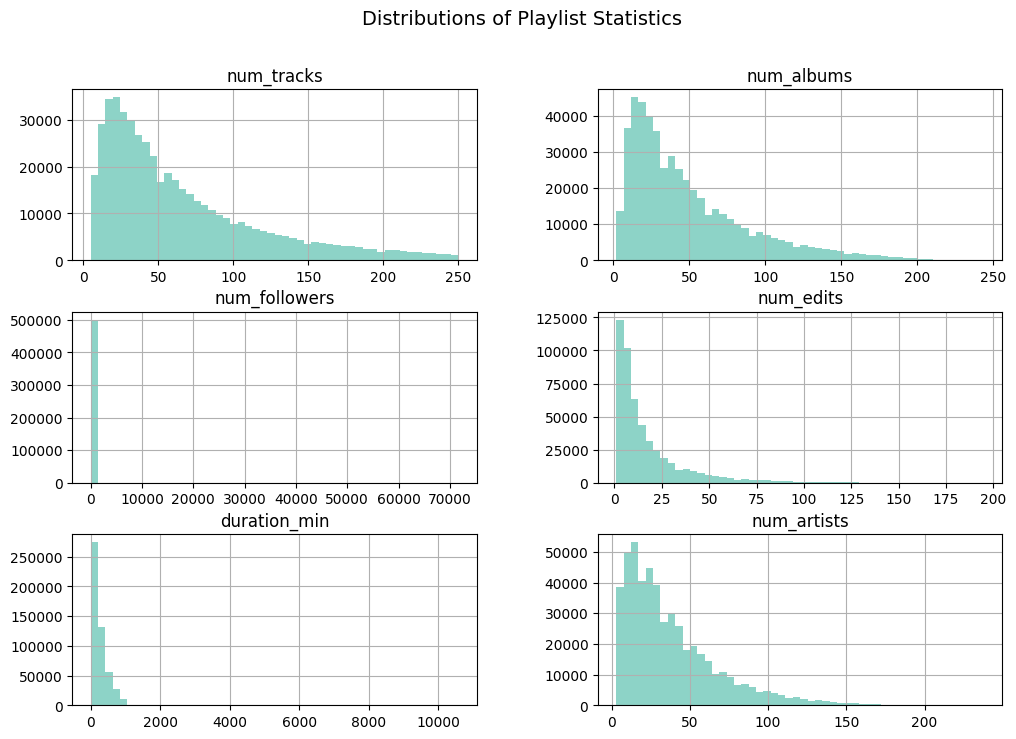

In [5]:
df['duration_min'] = df['duration_ms'] / 60000
numeric_cols = ['num_tracks','num_albums','num_followers','num_edits','duration_min','num_artists']

df[numeric_cols].describe()

df[numeric_cols].hist(bins=50, figsize=(12,8))
plt.suptitle("Distributions of Playlist Statistics", fontsize=14)
plt.show()

#### 4.3.1 Playlist Follower Distribution (log scale)
Follower counts are extremely skewed, with most playlists having very few followers.
Applying a log-transform reveals the long-tail distribution more clearly.

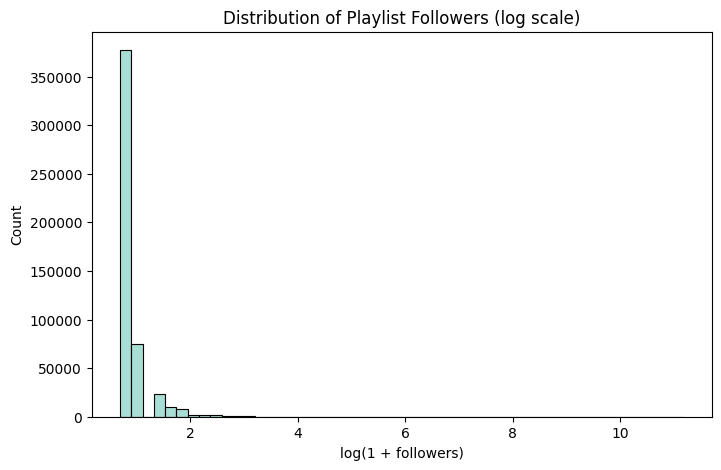

In [6]:
# Log-transform followers
plt.figure(figsize=(8,5))
sns.histplot(x=np.log1p(df['num_followers']), bins=50, kde=False)
plt.title("Distribution of Playlist Followers (log scale)")
plt.xlabel("log(1 + followers)")
plt.ylabel("Count")
plt.show()

### 4.4 Playlist Types
#### Collaborative vs Non-Collaborative

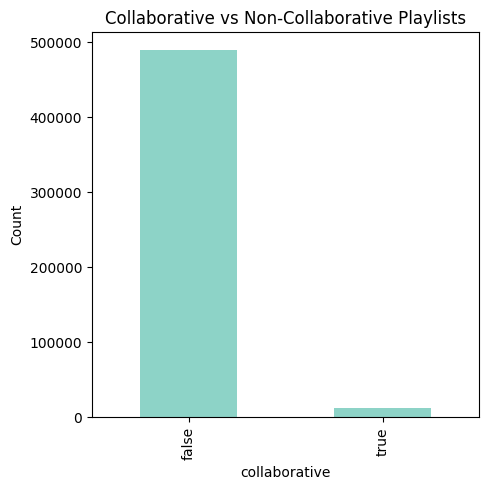

In [7]:
collab_counts = df['collaborative'].value_counts()
plt.figure(figsize=(5,5))
collab_counts.plot(kind="bar")
plt.title("Collaborative vs Non-Collaborative Playlists")
plt.ylabel("Count")
plt.show()


Most playlists are non-collaborative, suggesting that playlist creation is primarily an individual activity rather than collective.

---

### 4.5 Track & Artist Popularity
#### 4.5.1 Top 20 Artists

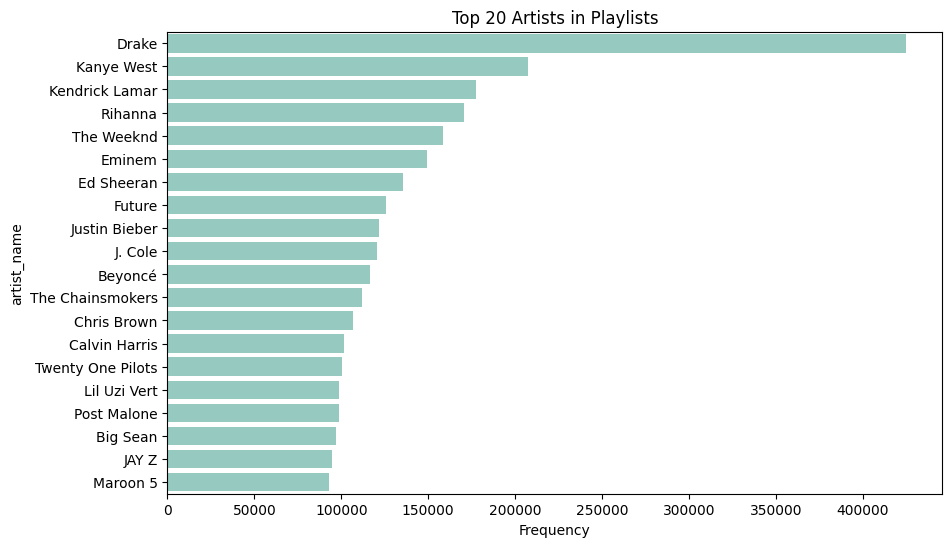

In [8]:
top_artists = tracks_df['artist_name'].value_counts().head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=top_artists.values, y=top_artists.index, orient="h")
plt.title("Top 20 Artists in Playlists")
plt.xlabel("Frequency")
plt.show()

#### 4.5.2 Top 20 Tracks

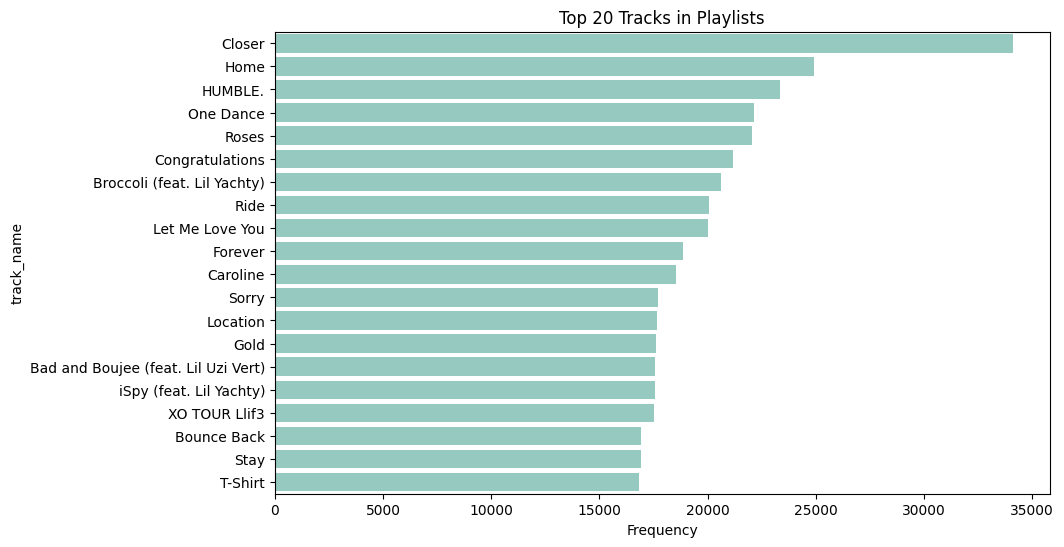

In [9]:
top_tracks = tracks_df['track_name'].value_counts().head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=top_tracks.values, y=top_tracks.index, orient="h")
plt.title("Top 20 Tracks in Playlists")
plt.xlabel("Frequency")
plt.show()

#### 4.5.3 Long-tail Popularity (Log Scale)

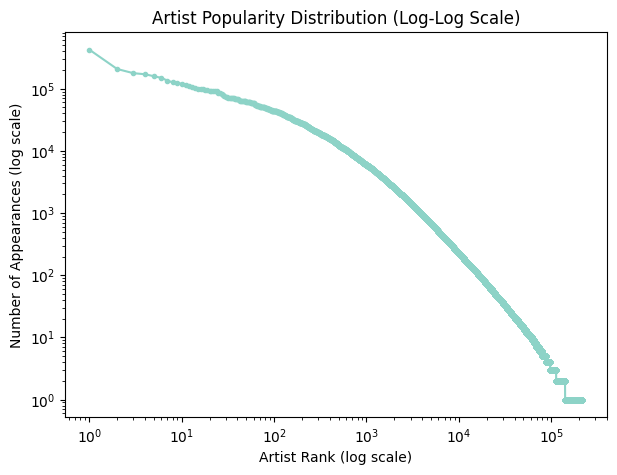

In [10]:
artist_counts = tracks_df['artist_name'].value_counts()
plt.figure(figsize=(7,5))
plt.loglog(range(1, len(artist_counts)+1), artist_counts.values, marker=".")
plt.xlabel("Artist Rank (log scale)")
plt.ylabel("Number of Appearances (log scale)")
plt.title("Artist Popularity Distribution (Log-Log Scale)")
plt.show()

This confirms the long-tail pattern: a few artists dominate, but the majority appear rarely.

---

### 4.6 Highlight Visualizations
#### 4.6.1 Top 20 Playlists by Followers

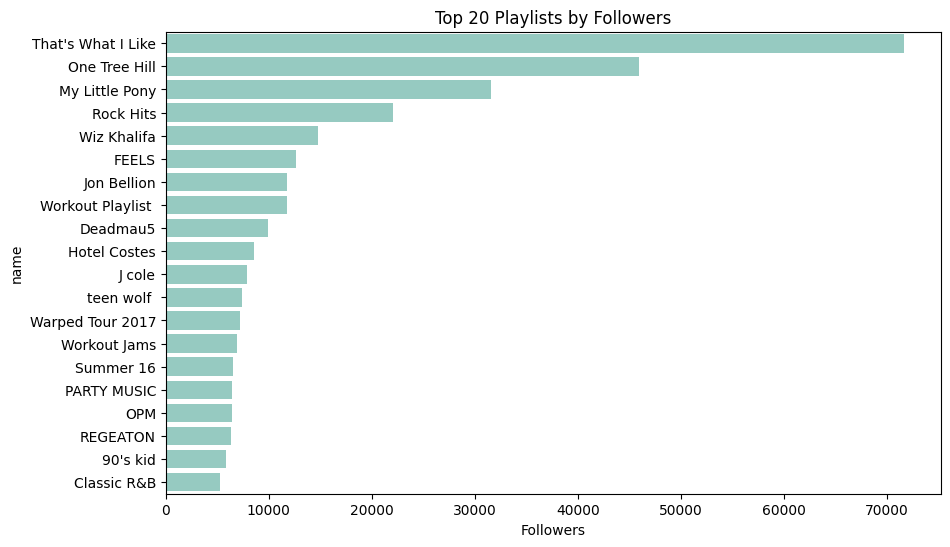

In [11]:
top_playlists = df.sort_values(by="num_followers", ascending=False).head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=top_playlists['num_followers'], y=top_playlists['name'], orient="h")
plt.title("Top 20 Playlists by Followers")
plt.xlabel("Followers")
plt.show()

#### 4.6.2 Violin Plot of Playlist Lengths

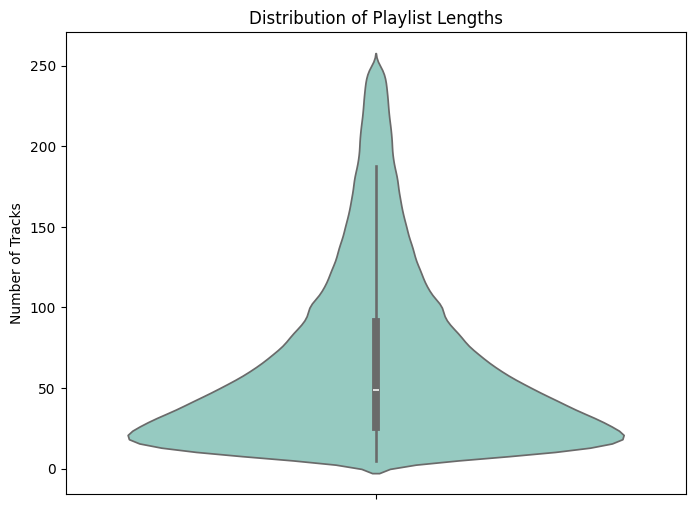

In [12]:
plt.figure(figsize=(8,6))
sns.violinplot(y=df['num_tracks'])
plt.title("Distribution of Playlist Lengths")
plt.ylabel("Number of Tracks")
plt.show()

## 4.7 Summary & Observations
### Key Observations

- **Playlist scale**: Most playlists are short (20–40 tracks), with a few very long playlists.
- **Followers**: Almost all playlists have close to **zero followers**; only a tiny minority attract large audiences.
- **Collaboration**: The overwhelming majority are **non-collaborative**, highlighting playlists as a personal curation tool.
- **Artist dominance**: A small set of artists (e.g., Drake, Kanye West, Rihanna, Eminem) dominate, while most artists appear rarely (classic **long-tail effect**).
- **Track popularity**: Similar concentration is observed in tracks, aligning with the “hit-driven” nature of the music industry.

These findings confirm that music recommendation must balance **popularity bias** (favoring well-known artists) with **diversity and novelty** (surfacing the long-tail).

## 4.8 Practical Constraints

While the original plan included **hybrid models** such as **LightFM with WARP loss**, memory constraints (32 GB RAM) made it infeasible to train at realistic dataset scales. Even subsets of 50k playlists caused kernel crashes, while reducing to 10k playlists would compromise representativeness.

As a result, we selected **ALS (Alternating Least Squares)** from the implicit library as our primary collaborative filtering approach, balancing **scalability, interpretability, and feasibility**.

## 4.9 Business Insight

From a product perspective, these findings highlight the challenge for Spotify:
- **Popularity bias** → Without personalization, recommendations will over-emphasize a handful of globally popular artists.
- **Long-tail opportunity** → Personalized models can improve **user satisfaction and discovery** by surfacing less obvious tracks and artists.
- **Scalability** → Any deployed solution must handle **extreme sparsity (~99.997%)** efficiently.
These constraints shape our design choices for the recommender system.

## 4.10 Next Steps
This notebook established a foundation by exploring the dataset and identifying core challenges (sparsity, long-tail distributions, popularity bias).

In the next notebooks, we will:
- **Notebook 02 – Baseline Popularity**: Implement a simple popularity-based recommender as a benchmark.
- **Notebook 03 – Data Preparation**: Build interaction matrices and create train/test splits.
- **Notebook 04 – ALS Collaborative Filtering**: Train and tune an ALS model with Optuna.
